In [1]:
import os
import librosa
import librosa.display
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from matplotlib.pyplot import specgram
import pandas as pd
import seaborn as sns
import glob 
import os
from tqdm import tqdm
import pickle
import IPython.display as ipd  # To play sound in the notebook
import soundfile as sf

import IPython.display as ipd
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
# Configuration from the notebook
DATASET_PATH = "dataset"
COMMANDS = ["baca", "berhenti", "foto", "halo", "info", "kembali", "ulang"]
SAMPLE_RATE = 16000
N_MFCC = 13
N_MELS = 22
WINDOW = int(SAMPLE_RATE * 0.01)
HOP = int(SAMPLE_RATE * 0.005)

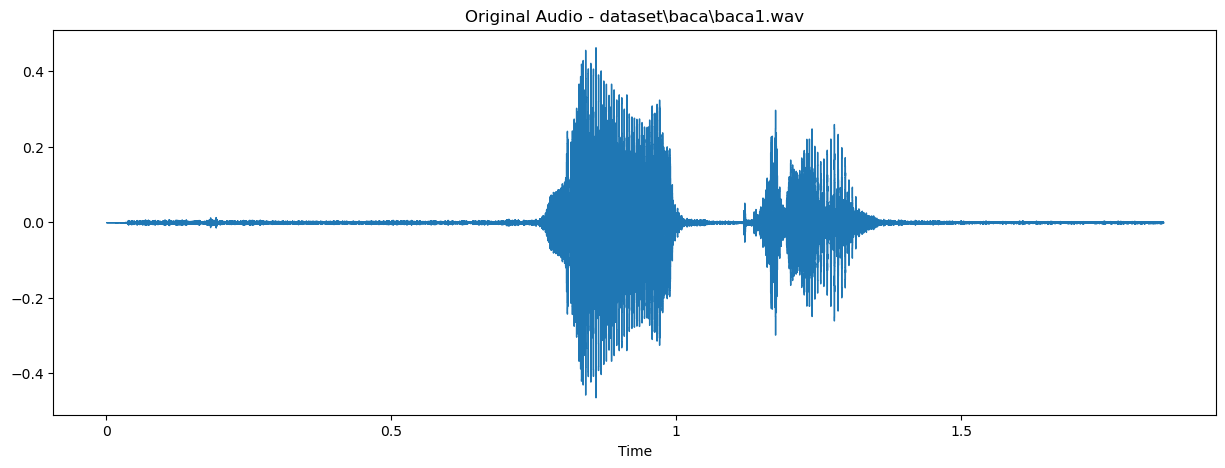

In [ ]:
def load_audio_files():
    audio_data = {}
    for label in COMMANDS:
        label_path = os.path.join(DATASET_PATH, label)
        if not os.path.exists(label_path):
            print(f"Directory {label_path} does not exist.")
            continue
        wav_files = glob.glob(os.path.join(label_path, "*.wav"))
        if wav_files:
            try:
                signal, sr = librosa.load(wav_files[0], sr=SAMPLE_RATE)
                audio_data[label] = (signal, sr)
            except Exception as e:
                print(f"Error loading {wav_files[0]}: {e}")
        else:
            print(f"No .wav files found in {label_path}")
    return audio_data

# Load audio files
audio_data = load_audio_files()

In [ ]:
for label, (signal, sr) in audio_data.items():
    plt.figure(figsize=(10, 4))
    librosa.display.waveshow(signal, sr=sr)
    plt.title(f"Original Signal: {label}")
    plt.xlabel("Time")
    plt.ylabel("Amplitude")
    plt.show()
    print(f"Playing original audio for label: {label}")
    display(ipd.Audio(signal, rate=sr))

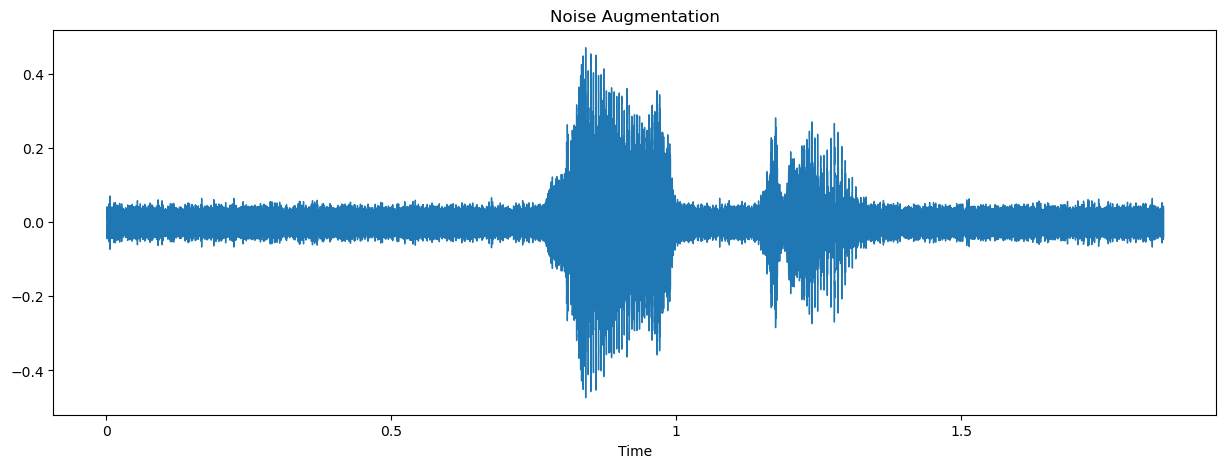

In [4]:
def noise(data):
    noise_amp = 0.05 * np.random.uniform() * np.amax(data)
    data = data.astype('float64') + noise_amp * np.random.normal(size=data.shape[0])
    return data

# Apply
x = noise(data)
plt.figure(figsize=(15, 5))
librosa.display.waveshow(x, sr=sampling_rate)
plt.title("Noise Augmentation")
plt.show()
ipd.Audio(x, rate=sampling_rate)

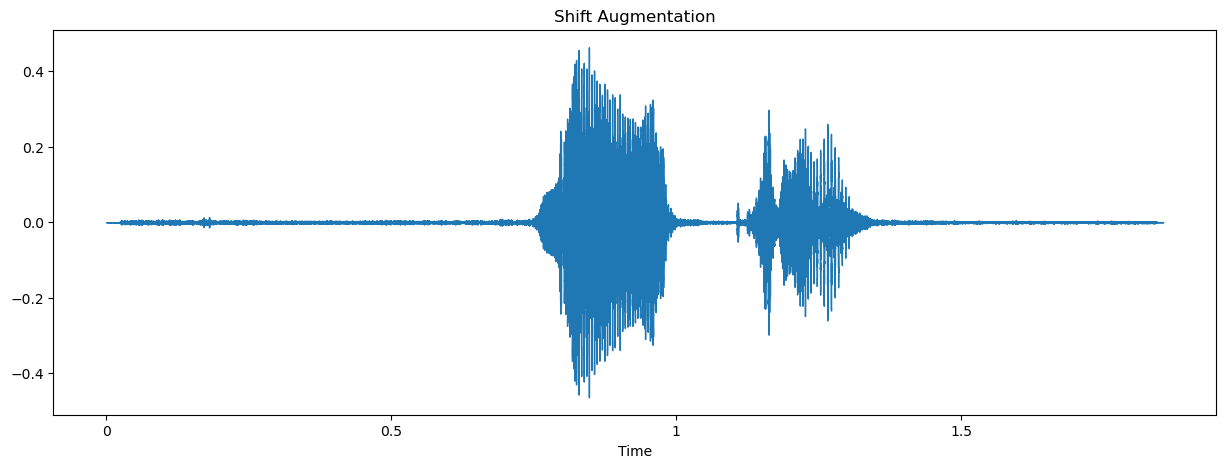

In [5]:
# def shift(data):
#     s_range = int(np.random.uniform(low=-5, high=5) * 1000)
#     return np.roll(data, s_range)

def shift(data, shift_fraction=0.05):
    max_shift = int(len(data) * shift_fraction)
    shift_amt = np.random.randint(-max_shift, max_shift)
    return np.roll(data, shift_amt)

x = shift(data, shift_fraction=0.05)

plt.figure(figsize=(15, 5))
librosa.display.waveshow(x, sr=sampling_rate)
plt.title("Shift Augmentation")
plt.show()

ipd.Audio(x, rate=sampling_rate)


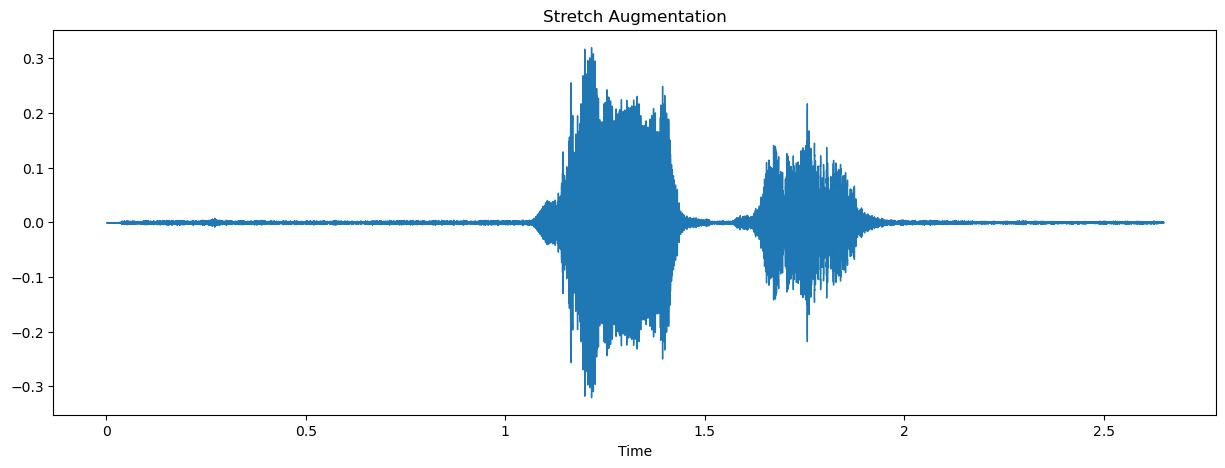

In [6]:
def stretch(data, rate=0.7):
    return librosa.effects.time_stretch(data, rate=rate)

x = stretch(data)
plt.figure(figsize=(15, 5))
librosa.display.waveshow(x, sr=sampling_rate)
plt.title("Stretch Augmentation")
plt.show()
ipd.Audio(x, rate=sampling_rate)

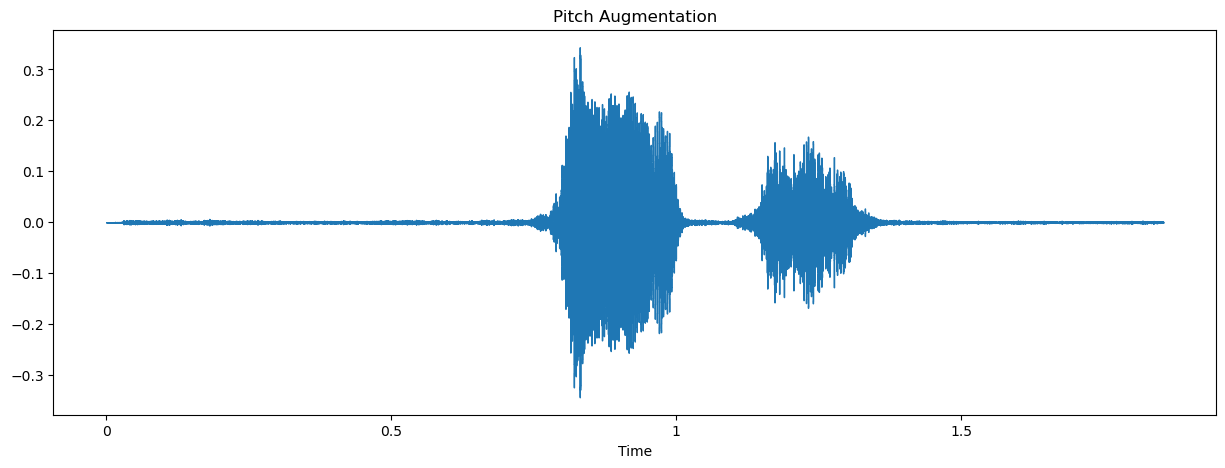

In [7]:
def pitch(data, sample_rate):
    bins_per_octave = 12
    pitch_pm = 2
    pitch_change = pitch_pm * 2 
    data = librosa.effects.pitch_shift(y=data.astype('float64'), 
                                       sr=sample_rate, 
                                       n_steps=pitch_change, 
                                       bins_per_octave=bins_per_octave)
    return data


x = pitch(data, sampling_rate)
plt.figure(figsize=(15, 5))
librosa.display.waveshow(x, sr=sampling_rate)
plt.title("Pitch Augmentation")
plt.show()
ipd.Audio(x, rate=sampling_rate)


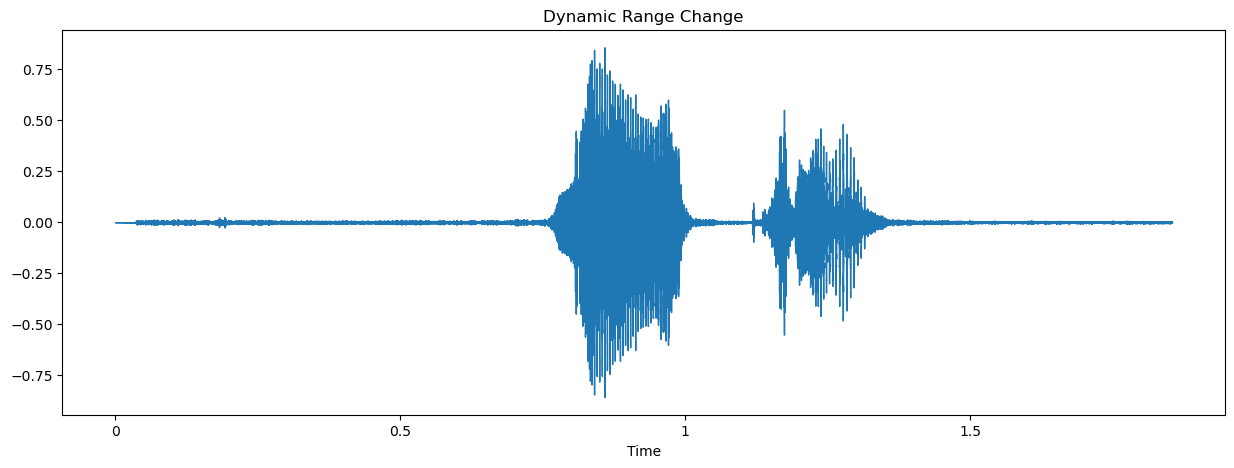

In [8]:
def dyn_change(data):
    dyn = np.random.uniform(low=0.3, high=2.0)
    return data * dyn

x = dyn_change(data)
plt.figure(figsize=(15, 5))
librosa.display.waveshow(x, sr=sampling_rate)
plt.title("Dynamic Range Change")
plt.show()
ipd.Audio(x, rate=sampling_rate)


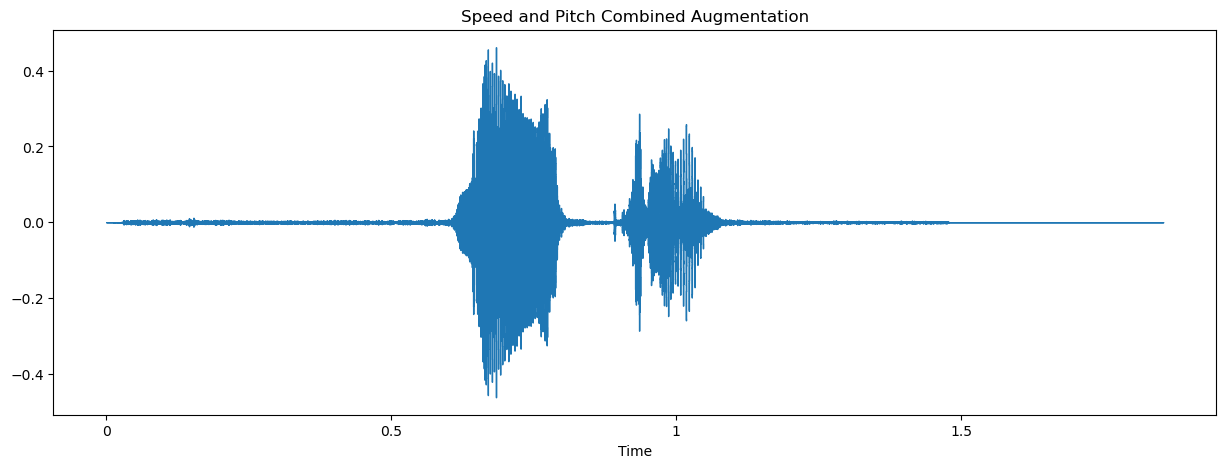

In [9]:
def speedNpitch(data):
    length_change = np.random.uniform(low=0.8, high=1)
    speed_fac = 1.2 / length_change
    tmp = np.interp(np.arange(0, len(data), speed_fac), np.arange(0, len(data)), data)
    minlen = min(len(data), len(tmp))
    data = np.zeros_like(data)
    data[0:minlen] = tmp[0:minlen]
    return data

x = speedNpitch(data)
plt.figure(figsize=(15, 5))
librosa.display.waveshow(x, sr=sampling_rate)
plt.title("Speed and Pitch Combined Augmentation")
plt.show()
ipd.Audio(x, rate=sampling_rate)


In [10]:
# MFCC extraction function
def extract_mfcc(signal):
    return librosa.feature.mfcc(
        y=signal,  
        sr=SAMPLE_RATE,
        n_mfcc=N_MFCC,
        n_mels=N_MELS,
        n_fft=WINDOW,
        hop_length=HOP
    ).T

In [11]:
# Encoding and padding function
def encode_and_pad(df_train, df_valid):
    le = LabelEncoder()
    df_train['label_encoded'] = le.fit_transform(df_train['label'])
    df_valid['label_encoded'] = le.transform(df_valid['label'])
    all_mfcc = df_train['mfcc'].tolist() + df_valid['mfcc'].tolist()
    max_len = max(len(x) for x in all_mfcc)
    X_train = pad_sequences(df_train['mfcc'], maxlen=max_len, padding='post', dtype='float32')
    X_valid = pad_sequences(df_valid['mfcc'], maxlen=max_len, padding='post', dtype='float32')
    y_train = to_categorical(df_train['label_encoded'])
    y_valid = to_categorical(df_valid['label_encoded'])
    return X_train, y_train, X_valid, y_valid, le

In [12]:
# Function to load one audio file per label
def load_audio_files():
    audio_data = {}
    for label in COMMANDS:
        # Assuming files are in DATASET_PATH/label/*.wav
        label_path = os.path.join(DATASET_PATH, label)
        if not os.path.exists(label_path):
            print(f"Directory {label_path} does not exist.")
            continue
        wav_files = glob.glob(os.path.join(label_path, "*.wav"))
        if wav_files:
            # Load the first .wav file for this label
            signal, sr = librosa.load(wav_files[0], sr=SAMPLE_RATE)
            audio_data[label] = (signal, sr)
        else:
            print(f"No .wav files found in {label_path}")
    return audio_data

In [13]:
# Function to visualize signals and spectrograms
def visualize_audio(audio_data):
    for label, (signal, sr) in audio_data.items():
        # Original signal
        plt.figure(figsize=(15, 5))
        plt.subplot(2, 2, 1)
        librosa.display.waveshow(signal, sr=sr)
        plt.title(f"Original Signal: {label}")
        
        # Mel Spectrogram
        plt.subplot(2, 2, 2)
        mel_spec = librosa.feature.melspectrogram(y=signal, sr=sr, n_mels=N_MELS, n_fft=WINDOW, hop_length=HOP)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        librosa.display.specshow(mel_spec_db, sr=sr, hop_length=HOP, x_axis='time', y_axis='mel')
        plt.colorbar(format='%+2.0f dB')
        plt.title(f"Mel Spectrogram: {label}")
        
        # Augmented signal
        augmented_signal = speedNpitch(signal)
        plt.subplot(2, 2, 3)
        librosa.display.waveshow(augmented_signal, sr=sr)
        plt.title(f"Augmented Signal: {label}")
        
        # Display audio
        print(f"\nPlaying original audio for label: {label}")
        display(ipd.Audio(signal, rate=sr))
        
        plt.tight_layout()
        plt.show()

In [14]:
# Function to create dataframe with MFCCs
def create_mfcc_dataframe(audio_data):
    data = []
    for label, (signal, sr) in audio_data.items():
        mfcc = extract_mfcc(signal)
        data.append({'label': label, 'mfcc': mfcc})
    df = pd.DataFrame(data)
    return df


Playing original audio for label: baca


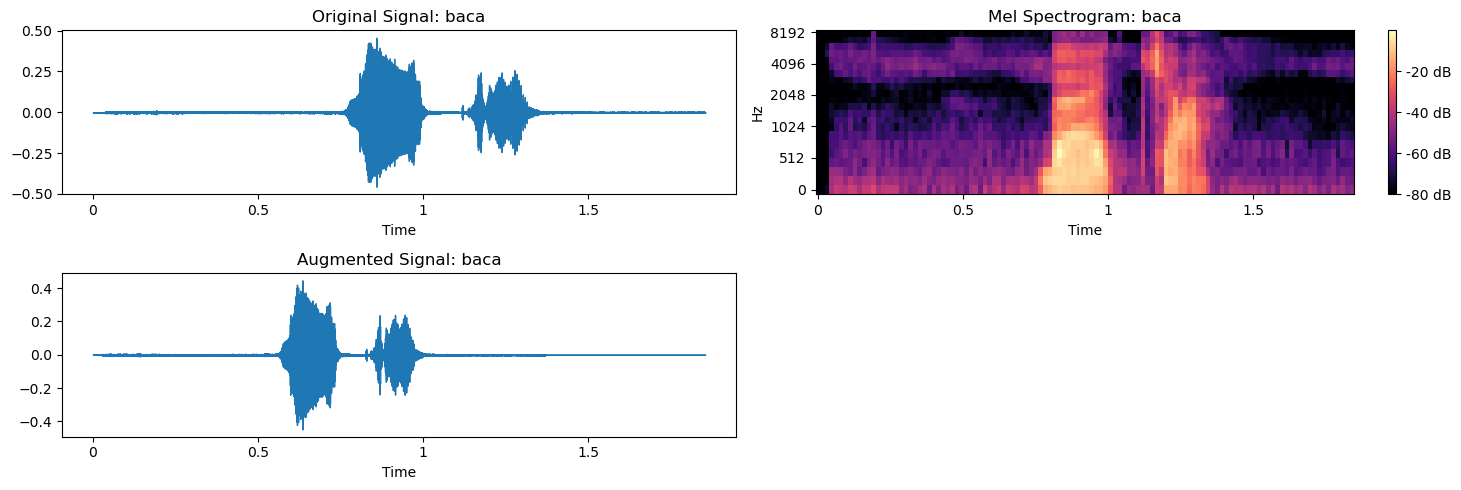


Playing original audio for label: berhenti


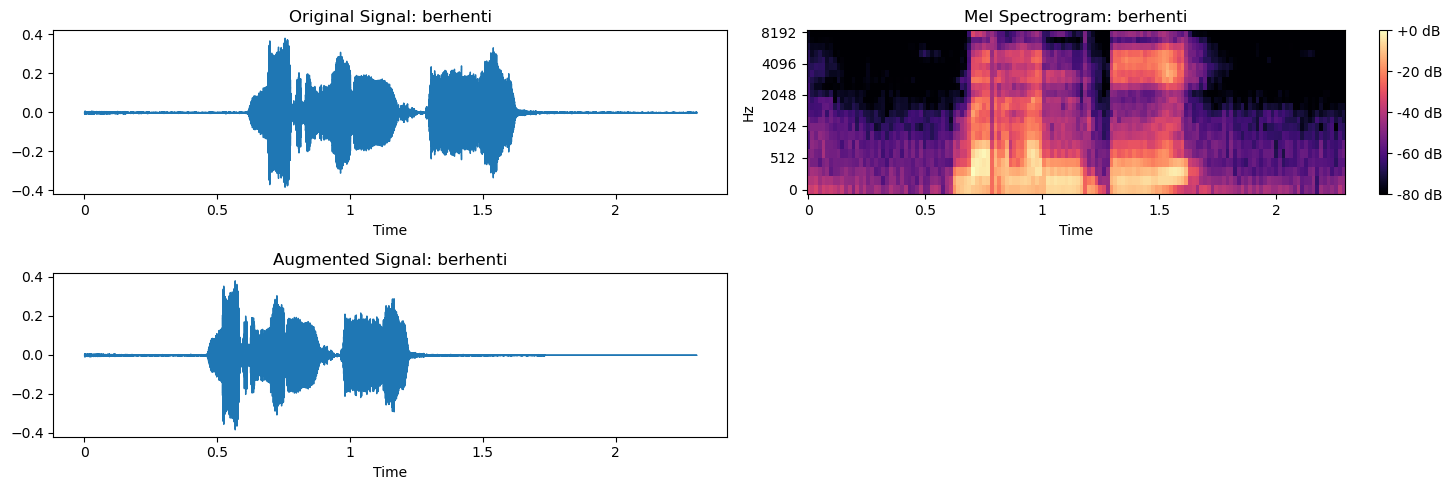


Playing original audio for label: foto


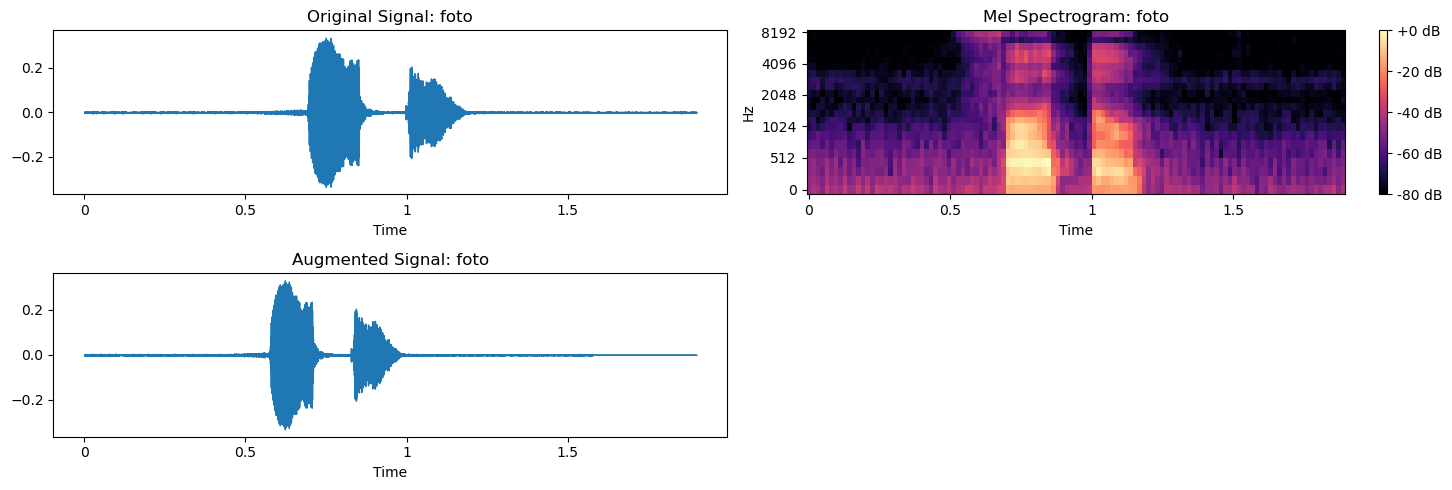


Playing original audio for label: halo


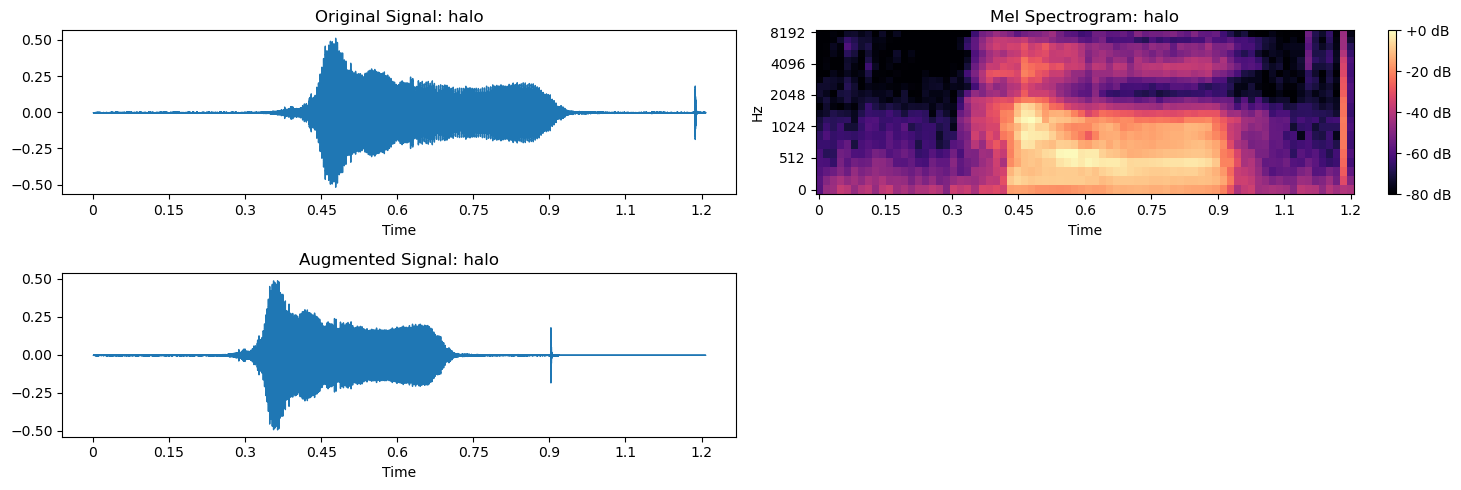


Playing original audio for label: info


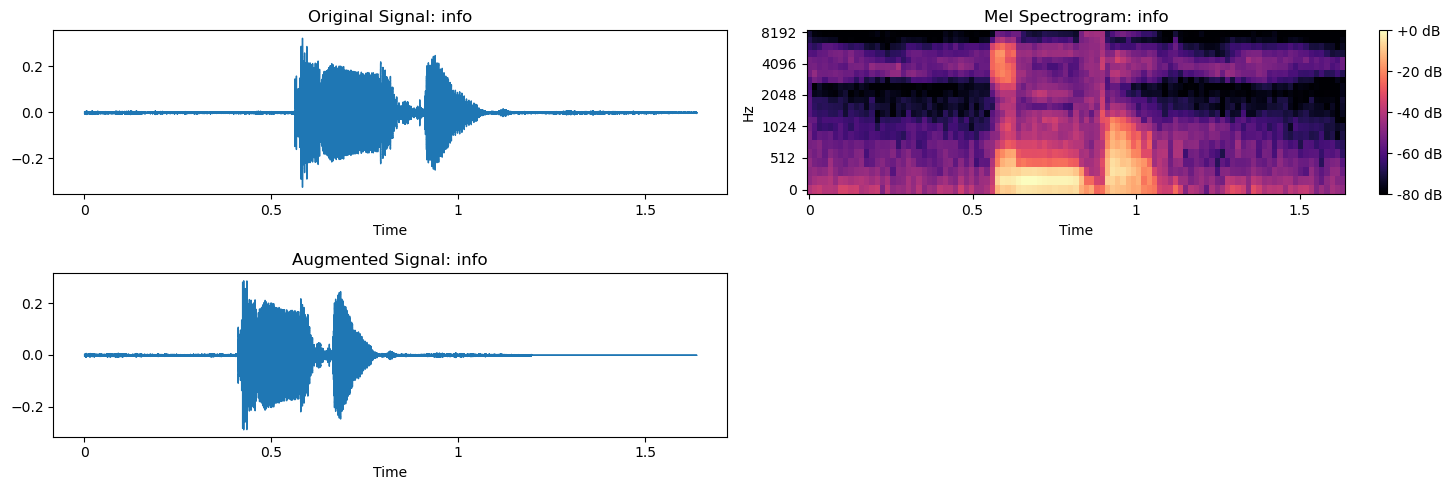


Playing original audio for label: kembali


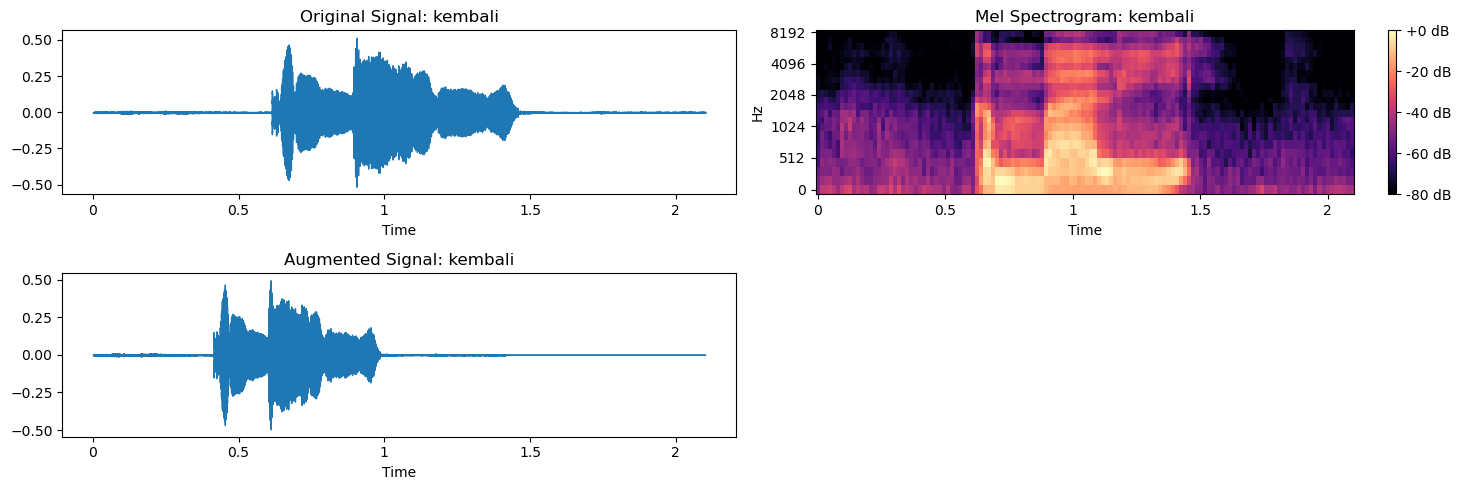


Playing original audio for label: ulang


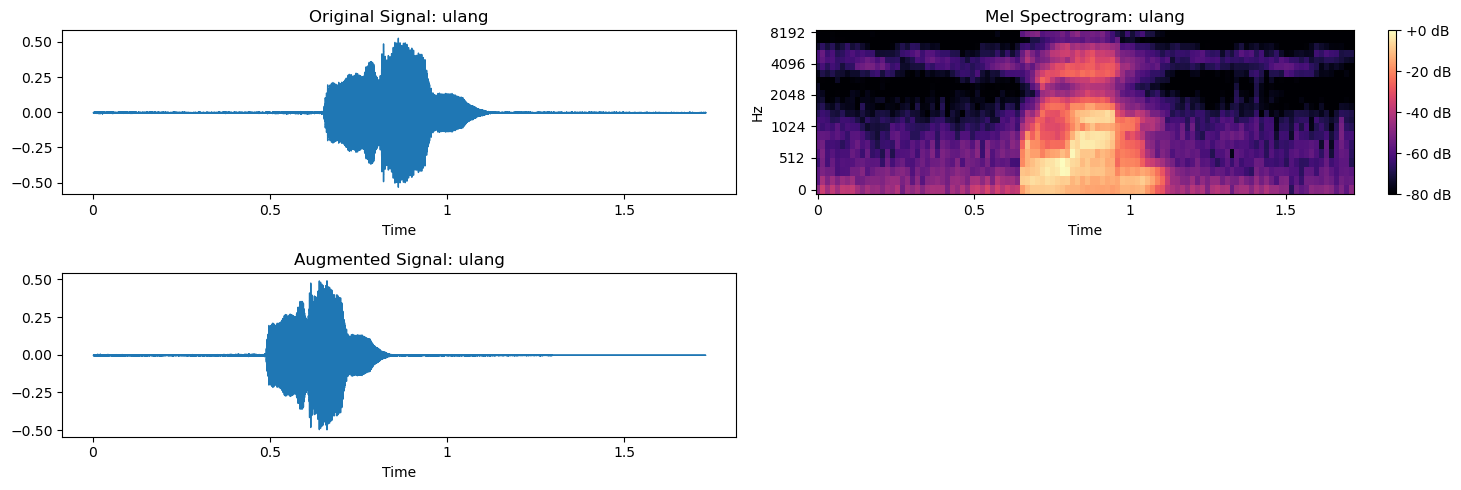


MFCC DataFrame:


,label,mfcc
0,baca,"[[-385.64957, 0.0, -9.107739e-06, 0.0, 0.0, 0...."
1,berhenti,"[[-290.6537, 43.3011, 6.1797523, 13.070197, 6...."
2,foto,"[[-336.7292, 46.622414, 14.83947, 15.672823, -..."
3,halo,"[[-359.14804, 35.221832, 10.320348, 3.0360827,..."
4,info,"[[-280.09152, 26.1128, 4.060148, 11.953274, -1..."
5,kembali,"[[-330.4393, 42.331512, 2.659122, 3.4952478, 1..."
6,ulang,"[[-322.49048, 31.25511, 11.654533, -1.3667905,..."


ValueError: y contains previously unseen labels: 'ulang'

In [15]:
# Main execution
if __name__ == "__main__":
    # Load audio files
    audio_data = load_audio_files()
    
    # Visualize signals and spectrograms
    visualize_audio(audio_data)
    
    # Create dataframe with MFCCs
    df = create_mfcc_dataframe(audio_data)
    print("\nMFCC DataFrame:")
    display(df)
    
    # For encoding and padding, split into train and valid (dummy split for demonstration)
    df_train = df.sample(frac=0.8, random_state=42)
    df_valid = df.drop(df_train.index)
    
    # Encode and pad
    X_train, y_train, X_valid, y_valid, le = encode_and_pad(df_train, df_valid)
    
    # Create final dataframe for encoded data
    final_data = []
    for i, label in enumerate(df_train['label']):
        final_data.append({
            'label': label,
            'label_encoded': le.transform([label])[0],
            'mfcc_shape': X_train[i].shape,
            'y_shape': y_train[i].shape
        })
    for i, label in enumerate(df_valid['label']):
        final_data.append({
            'label': label,
            'label_encoded': le.transform([label])[0],
            'mfcc_shape': X_valid[i].shape,
            'y_shape': y_valid[i].shape
        })
    final_df = pd.DataFrame(final_data)
    print("\nFinal Encoded and Padded DataFrame:")
    display(final_df)